# Bates Model

**What this is:** Bates (1996) combines Heston stochastic volatility with Merton's jump
component, so the price is driven by a diffusive variance process and a compound Poisson
jump term at the same time.

**Why it matters:** The motivation here is empirical. Stochastic volatility on its own
produces a realistic skew at long maturities while failing to generate the steep smile
observed in short dated options, due to a diffusion not being able to travel far in a
small amount of time. Jumps supply exactly that short horizon tail. It is worth noting
that this notebook shares its variance process with the Heston notebook through
`src/models.py`.

## Setup

In [1]:
import sys, pathlib

# Walk up to the repository root (the directory containing `src/`) so this
# notebook imports the same way regardless of how deeply it is nested.
REPO_ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                 if (p / "src").is_dir())
sys.path.append(str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from src.models import simulate_bates
plt.style.use("seaborn-v0_8")

## Parameters

| Symbol | Code | Meaning |
|---|---|---|
| $S_0$ | `S0` | initial asset price |
| $\mu$ | `mu` | drift of the price process |
| $\kappa$ | `kappa` | mean reversion speed of the variance |
| $\theta$ | `theta` | long run variance level, also used as $v_0$ |
| $\xi$ | `xi` | volatility of volatility |
| $\rho$ | `rho` | correlation between the price and variance shocks |
| $\lambda$ | `lam` | jump intensity, the expected number of jumps per year |
| $\mu_j$ | `mu_j` | mean of the log jump size |
| $\sigma_j$ | `sigma_j` | standard deviation of the log jump size |
| $k$ | `k` | expected relative jump size, $k = e^{\mu_j + \frac{1}{2}\sigma_j^2} - 1$ |
| $T$ | `T` | time horizon in years |
| $n$ | `n` | number of time steps (252 trading days) |
| $\Delta t$ | `dt` | time step size, $\Delta t = T/n$ |

In [2]:
num_paths = 100
n = 252
T = 1
dt = T / n
S0 = 100
theta = 0.05
kappa = 6
xi = 0.4
rho = -0.7
mu = 0.03
lam = 1
mu_j = 0.05
sigma_j = 0.05

## Model

**Continuous time:** the variance process is identical to Heston, with a compound Poisson
jump term added to the price,

$$dS_t = \left( \mu - \lambda k \right) S_t \, dt + \sqrt{v_t} \, S_t \, dW^{S}_t
+ S_{t^-} \left( e^{Y} - 1 \right) dN_t$$

$$dv_t = \kappa \left( \theta - v_t \right) dt + \xi \sqrt{v_t} \, dW^{v}_t,
\qquad d\langle W^{S}, W^{v} \rangle_t = \rho \, dt$$

The compensator $\lambda k$ is subtracted from the drift so that the jumps leave the
expected return unchanged, where $k = e^{\mu_j + \frac{1}{2}\sigma_j^2} - 1$ is the
expected relative jump size.

**Jump component:** the number of jumps in a step is Poisson, and the total log jump over
that step is the sum of that many independent normal draws,

$$\Delta N_{i,j} \sim \text{Poisson}(\lambda \Delta t), \qquad
Y_{i,j} \sim \mathcal{N}\!\left( \mu_j \Delta N_{i,j},\ \sigma_j^2 \Delta N_{i,j} \right)$$

**Euler-Maruyama discretisation:** with $x^{+} = \max(x, 0)$ as in the Heston notebook,

$$v_{i+1,j} = v_{i,j} + \kappa \left( \theta - v^{+}_{i,j} \right) \Delta t
+ \xi \sqrt{v^{+}_{i,j}} \sqrt{\Delta t} \, \varepsilon^{v}_{i,j}$$

$$S_{i+1,j} = S_{i,j}
+ S_{i,j} \left( \mu - \lambda k \right) \Delta t
+ \sqrt{v^{+}_{i,j}} \, S_{i,j} \sqrt{\Delta t} \, \varepsilon^{S}_{i,j}
+ S_{i,j} \left( e^{Y_{i,j}} - 1 \right)$$

where $i$ indexes time and $j$ indexes paths, with $i \in [0, n-1]$ and $j \in [1, \texttt{num\_paths}]$.

**In code:** `simulate_bates` in `src/models.py`, which reuses
`simulate_cir_variance` and `generate_correlated_normals` from the Heston notebook rather
than duplicating them. Scaling the jump distribution by $\Delta N_{i,j}$ in both its mean
and its variance is what makes a step containing two jumps equivalent to two independent
single jumps.

## Results

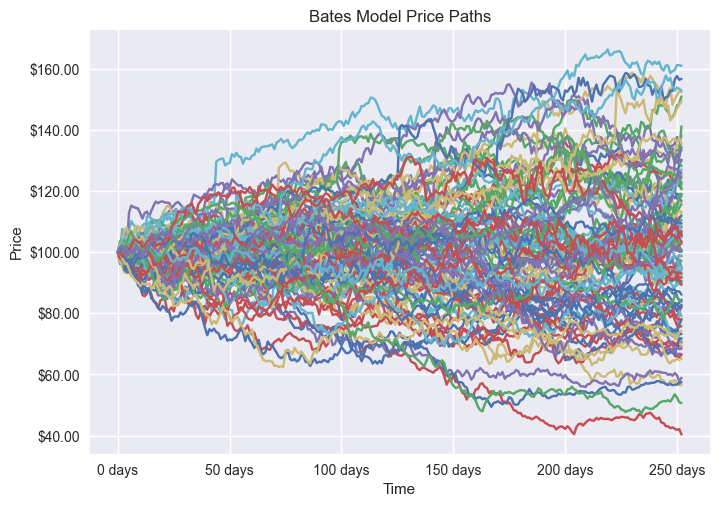

In [3]:
paths = simulate_bates(S0,n,dt,theta,kappa,xi,rho,mu,lam,mu_j,sigma_j,num_paths)

plt.plot(paths)
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Bates Model Price Paths")
plt.gca().yaxis.set_major_formatter("${x:,.2f}")
plt.gca().xaxis.set_major_formatter("{x:,.0f} days")
plt.show()